In [34]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MultipleLocator
from typing import Any
import numpy as np

ROOT = Path("D:\\programming\\velencei_to\\analysis")
TOWN = "Balaton - Átlag"
TOWN_NICKNAME = "Balaton"
filename = "balaton_20260617.csv"
# TOWN = "Velencei tó - Agárd"
# TOWN_NICKNAME = "Agard"
# filename = "agard_20260617.csv"

### Load, display data and clean

In [35]:
raw_data = pd.read_csv(ROOT / "data" / filename, sep=";")
raw_data.columns = ["timestamp", "water_level"]
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"])
display(raw_data.head())
display(raw_data.tail())

,timestamp,water_level
0,1979-12-31 08:00:00,90
1,1980-01-01 08:00:00,90
2,1980-01-02 08:00:00,89
3,1980-01-03 08:00:00,89
4,1980-01-04 08:00:00,90


,timestamp,water_level
16967,2026-06-13 07:00:00,78
16968,2026-06-14 07:00:00,78
16969,2026-06-15 07:00:00,78
16970,2026-06-16 07:00:00,78
16971,2026-06-17 07:00:00,77


In [36]:
# We keep the latest daily data point
# For some time periods we have measurement at 8.00 & 16.00, in another decause
# we have measurements at 7.00 & 19.00, so we keep the latest one of the day...
daily_last = (
    raw_data.sort_values("timestamp")
    .groupby(raw_data["timestamp"].dt.normalize(), as_index=False)
    .last()
)
daily_last["date"] = daily_last["timestamp"].dt.date
daily_last["diff"] = daily_last["water_level"].diff()
daily_last.dropna(inplace=True)
last_observation = daily_last.tail(1)

In [37]:
# We create historic data using 7 day periods (weekly changes)
# remove february 29th, because we want to have a regular 365 day year, and we will use dayofyear later
daily_last["date"] = pd.to_datetime(daily_last["date"])
daily_last = daily_last[
    ~((daily_last["date"].dt.month == 2) & (daily_last["date"].dt.day == 29))
]
daily_last["year"] = daily_last["date"].dt.year
daily_last["month"] = daily_last["date"].dt.month
daily_last["day"] = daily_last["date"].dt.day
daily_last["dayofyear_raw"] = daily_last["date"].dt.dayofyear

# leap year logic: if leap year we substract 1 from dayofyear for dates after february 28th
is_leap = (daily_last["year"] % 4 == 0) & (
    (daily_last["year"] % 100 != 0) | (daily_last["year"] % 400 == 0)
)
after_feb28 = daily_last["month"] > 2
daily_last["dayofyear"] = daily_last["dayofyear_raw"] - (is_leap & after_feb28)
#  7 day periods...
daily_last_7day = daily_last[daily_last["dayofyear"] % 7 == 0].copy()
daily_last_7day["diff"] = daily_last_7day["water_level"].diff()
# daily_last_7day.dropna(inplace=True)

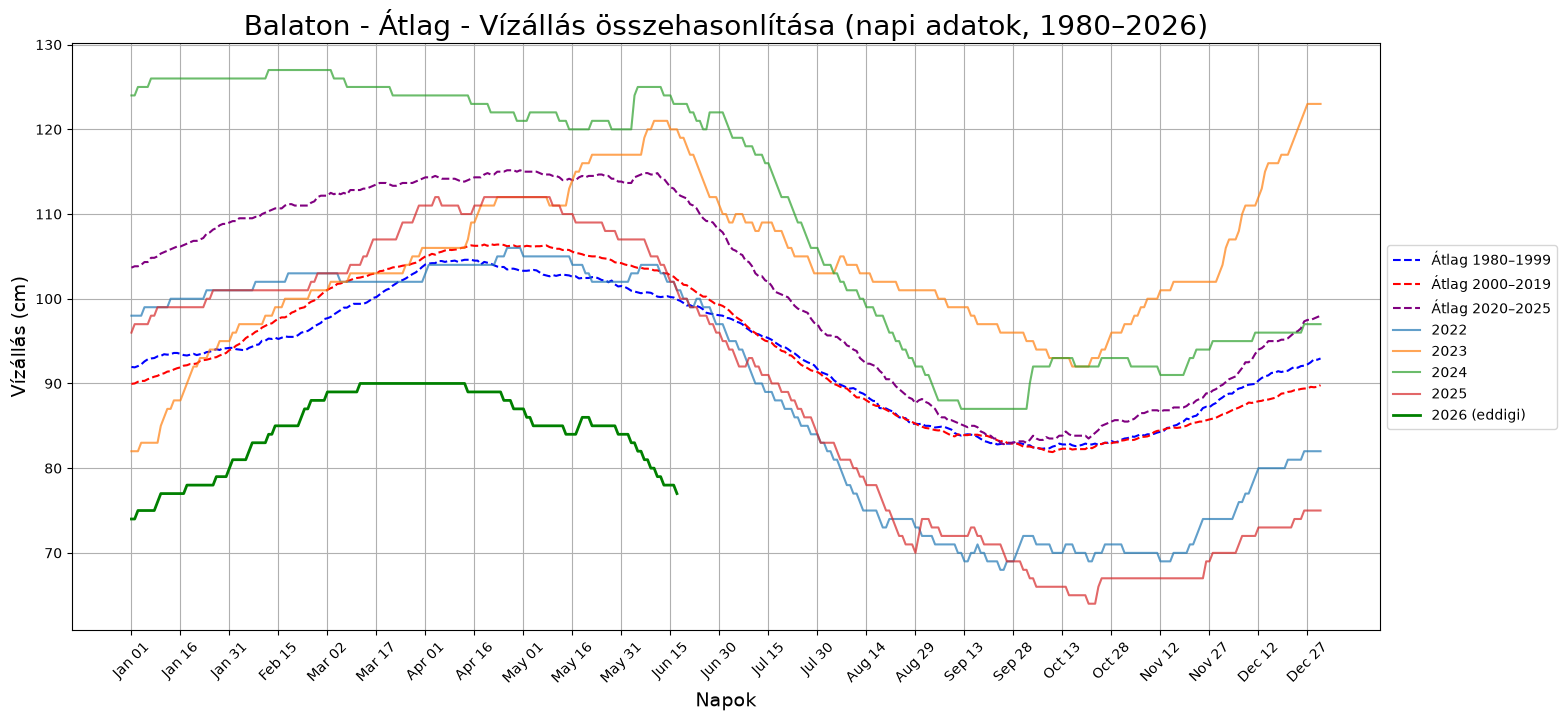

In [38]:
pivot = daily_last.pivot(index="dayofyear", columns="year", values="water_level")
avg_2020_2025 = pivot.loc[:, 2020:2025].mean(axis=1)
avg_1980_1999 = pivot.loc[:, 1980:1999].mean(axis=1)
avg_2000_2019 = pivot.loc[:, 2000:2019].mean(axis=1)

y2022 = pivot[2022]
y2023 = pivot[2023]
y2024 = pivot[2024]
y2025 = pivot[2025]
y2026 = pivot[2026]  # eddigi adatok

plt.figure(figsize=(14, 7))

plt.plot(avg_1980_1999, label="Átlag 1980–1999", linestyle="--", color="blue")
plt.plot(avg_2000_2019, label="Átlag 2000–2019", linestyle="--", color="red")
plt.plot(avg_2020_2025, label="Átlag 2020–2025", linestyle="--", color="purple")

plt.plot(y2022, label="2022", alpha=0.7)
plt.plot(y2023, label="2023", alpha=0.7)
plt.plot(y2024, label="2024", alpha=0.7)
plt.plot(y2025, label="2025", alpha=0.7)

plt.plot(y2026, label="2026 (eddigi)", linewidth=2, color="green")

plt.title(
    f"{TOWN} - Vízállás összehasonlítása (napi adatok, 1980–2026)",
    fontsize=20,
)
plt.xlabel("Napok", fontsize=14)
plt.ylabel("Vízállás (cm)", fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

standard_dates = pd.date_range("2001-01-01", "2001-12-31", freq="D")
date_labels = standard_dates.strftime("%b %d")
plt.xticks(
    ticks=range(1, 366, 15),
    labels=date_labels[::15],
    rotation=45,
)
plt.savefig(
    ROOT / "exploration" / f"vizallas_1980_2026_{TOWN_NICKNAME}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Minimum water level and annual water level change comparison

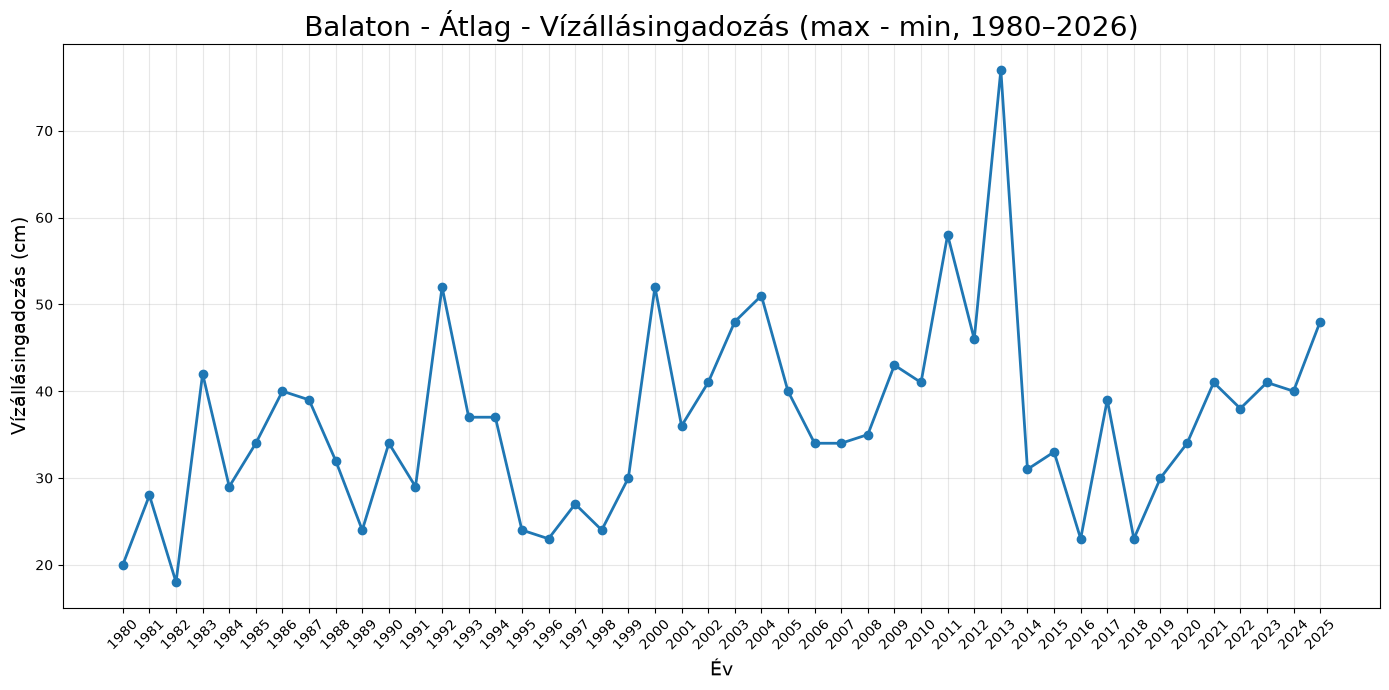

In [39]:
annual_fluctuation = pivot.max() - pivot.min()
annual_fluctuation = annual_fluctuation[annual_fluctuation.index < 2026]

plt.figure(figsize=(14, 7))
plt.plot(annual_fluctuation.index, annual_fluctuation.values, marker="o", linewidth=2)

plt.title(
    f"{TOWN} - Vízállásingadozás (max - min, 1980–2026)",
    fontsize=20,
)
plt.xlabel("Év", fontsize=14)
plt.ylabel("Vízállásingadozás (cm)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(annual_fluctuation.index)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    ROOT / "exploration" / f"vizallasingadozas_1980_2026_{TOWN_NICKNAME}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

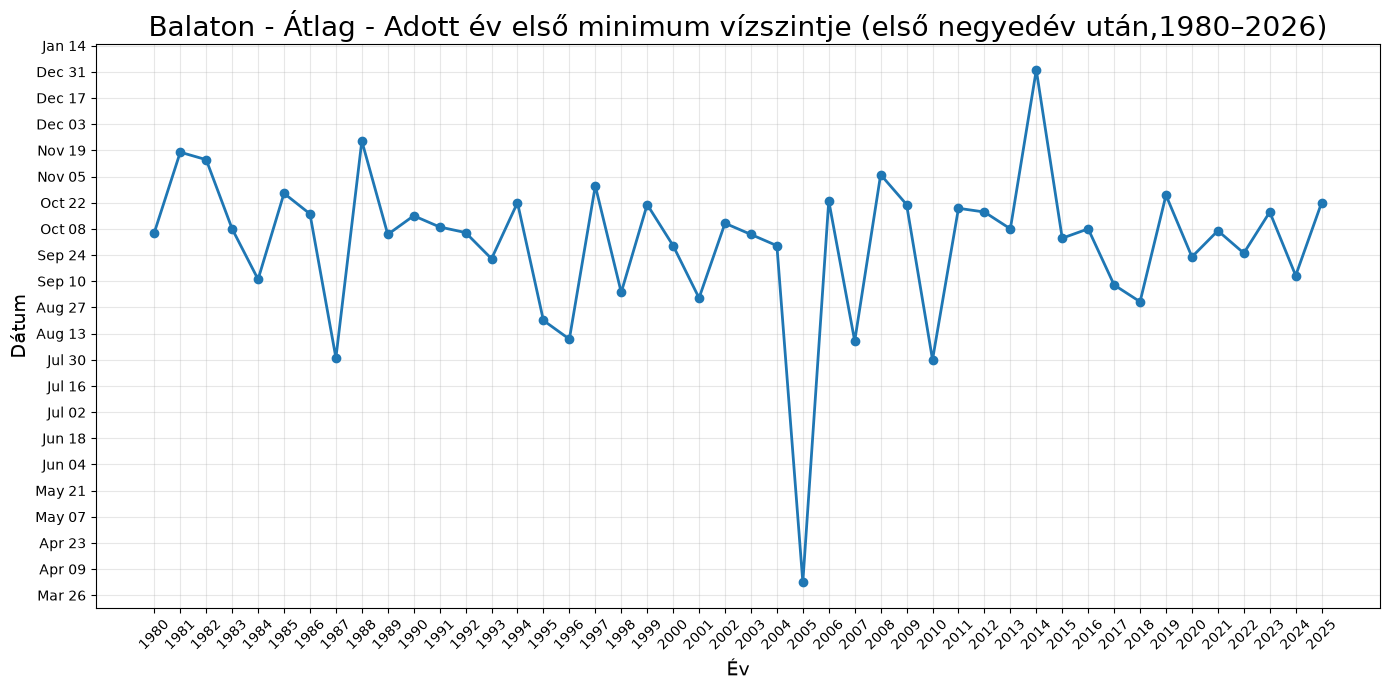

In [40]:
min_days = pivot[pivot.index > 90].idxmin()
min_days = min_days[min_days.index < 2026]
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(min_days.index, min_days.values, marker="o", linewidth=2)


def doy_to_date(x, pos):
    try:
        date = datetime(2001, 1, 1) + timedelta(days=int(x))
        return date.strftime("%b %d")
    except Exception:
        return ""


ax.yaxis.set_major_locator(MultipleLocator(14))
ax.yaxis.set_major_formatter(FuncFormatter(doy_to_date))

ax.set_title(
    f"{TOWN} - Adott év első minimum vízszintje (első negyedév után,1980–2026)",
    fontsize=20,
)
ax.set_xlabel("Év", fontsize=14)
ax.set_ylabel("Dátum", fontsize=14)

ax.set_xticks(min_days.index)
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)

plt.savefig(
    ROOT / "exploration" / f"min_days_1980_2026_{TOWN_NICKNAME}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.tight_layout()
plt.show()

# Notes...
# There were some years when the first minimum water level was in the first quarter of the year,ű
# as there was dynamic growth in the first quarter.
# The water level started to decrease after early spring, to finally reach the second minimum in the summer
# and than start to increase again in the autumn.
# This is why we only consider the first minimum after the first quarter of the year.
# This chart tries to explain that in a given year up until mid October,
# we may see water levels decrease

### Forecast based on weekly changes

In [41]:
def fan_chart_simulation(
    daily_last_7day: pd.DataFrame,
    start_year: int,
    end_year: int,
    last_day: int,
    n_sims: int = 1000,
) -> dict[str, Any]:
    """
    Generate a bootstrap-based fan chart simulation using weekly water level changes.

    Parameters
    ----------
    daily_last_7day : pd.DataFrame
        Weekly dataset containing at least the columns:
        ['year', 'dayofyear', 'water_level', 'diff'].
        'diff' must represent the weekly change in water level.
    start_year : int
        First year (inclusive) of the historical sampling window.
    end_year : int
        Last year (inclusive) of the historical sampling window.
    last_day : int
        Last known day-of-year value (e.g., 161 for June 10).
        Simulation starts AFTER this day.
    n_sims : int, optional
        Number of bootstrap simulation paths to generate (default: 1000).

    Returns
    -------
    Dict[str, Any]
        {
            "grid_days": List[int],     # future day-of-year values
            "simulations": np.ndarray,  # shape (n_sims, len(grid_days))
            "p10": np.ndarray,          # 10th percentile forecast
            "p50": np.ndarray,          # median forecast
            "p90": np.ndarray,          # 90th percentile forecast
            "last_value": float         # last observed water level
        }

    Notes
    -----
    - The method uses historical weekly diffs (changes) from the selected
    time window and samples them with replacement (bootstrap).
    - The simulation proceeds forward in weekly steps (7-day increments).
    - Missing diff values for a given day-of-year are treated as zero change.
    """

    # --- 1) Filter historical sampling window ---
    scope = daily_last_7day[
        (daily_last_7day["year"] >= start_year) & (daily_last_7day["year"] <= end_year)
    ]

    # --- 2) Group diffs by day-of-year (sampling pool) ---
    diff_by_day = scope.groupby("dayofyear")["diff"].apply(list)

    # --- 3) Create future grid: weekly steps until day 365 ---
    grid_days: list[int] = list(range(last_day + 7, 366, 7))

    # --- 4) Last observed water level ---
    last_value_row = daily_last_7day[daily_last_7day["dayofyear"] == last_day]
    if last_value_row.empty:
        raise ValueError(f"No data found for last_day={last_day}")
    last_value: float = float(last_value_row.iloc[-1]["water_level"])

    # --- 5) Allocate simulation matrix ---
    sims = np.zeros((n_sims, len(grid_days)))

    # --- 6) Bootstrap simulation ---
    for i in range(n_sims):
        value = last_value
        for j, d in enumerate(grid_days):

            # If no historical diffs exist for this day, assume zero change
            if d not in diff_by_day:
                sampled_diff = 0.0
            else:
                sampled_diff = float(np.random.choice(diff_by_day[d]))

            value += sampled_diff
            sims[i, j] = value

    return {
        "grid_days": grid_days,
        "simulations": sims,
        "p05": np.percentile(sims, 5, axis=0),
        "p10": np.percentile(sims, 10, axis=0),
        "p25": np.percentile(sims, 25, axis=0),
        "p50": np.percentile(sims, 50, axis=0),
        "p75": np.percentile(sims, 75, axis=0),
        "p90": np.percentile(sims, 90, axis=0),
        "p95": np.percentile(sims, 95, axis=0),
        "last_value": last_value,
    }

In [42]:
last_day = daily_last_7day.tail(1)["dayofyear"].values[0]

# Historical diffs
diff_2000_2019 = (
    daily_last_7day[
        (daily_last_7day["year"] >= 2000) & (daily_last_7day["year"] <= 2019)
    ]
    .groupby("dayofyear")["diff"]
    .mean()
)

diff_2020_2025 = (
    daily_last_7day[
        (daily_last_7day["year"] >= 2020) & (daily_last_7day["year"] <= 2025)
    ]
    .groupby("dayofyear")["diff"]
    .mean()
)

# Only future diffs (after last_day)
diff_2000_2019_future = diff_2000_2019[diff_2000_2019.index > last_day]
diff_2020_2025_future = diff_2020_2025[diff_2020_2025.index > last_day]

# Last observed water level
last_value = daily_last_7day.iloc[-1]["water_level"]

# naive forecasts
forecast_2000_2019 = last_value + diff_2000_2019_future.cumsum()
forecast_2020_2025 = last_value + diff_2020_2025_future.cumsum()

current_year = daily_last_7day.tail(1)["year"].values[0]
realized = daily_last_7day[
    (daily_last_7day["year"] == current_year)
    & (daily_last_7day["dayofyear"] <= last_day)
]

result = fan_chart_simulation(
    daily_last_7day,
    start_year=2010,
    end_year=2025,
    last_day=last_day,
    n_sims=10000,
)
print(result.keys())

grid_days = result["grid_days"]
p10 = result["p10"]
p50 = result["p50"]
p90 = result["p90"]
p05 = result["p05"]
p95 = result["p95"]

dict_keys(['grid_days', 'simulations', 'p05', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'last_value'])


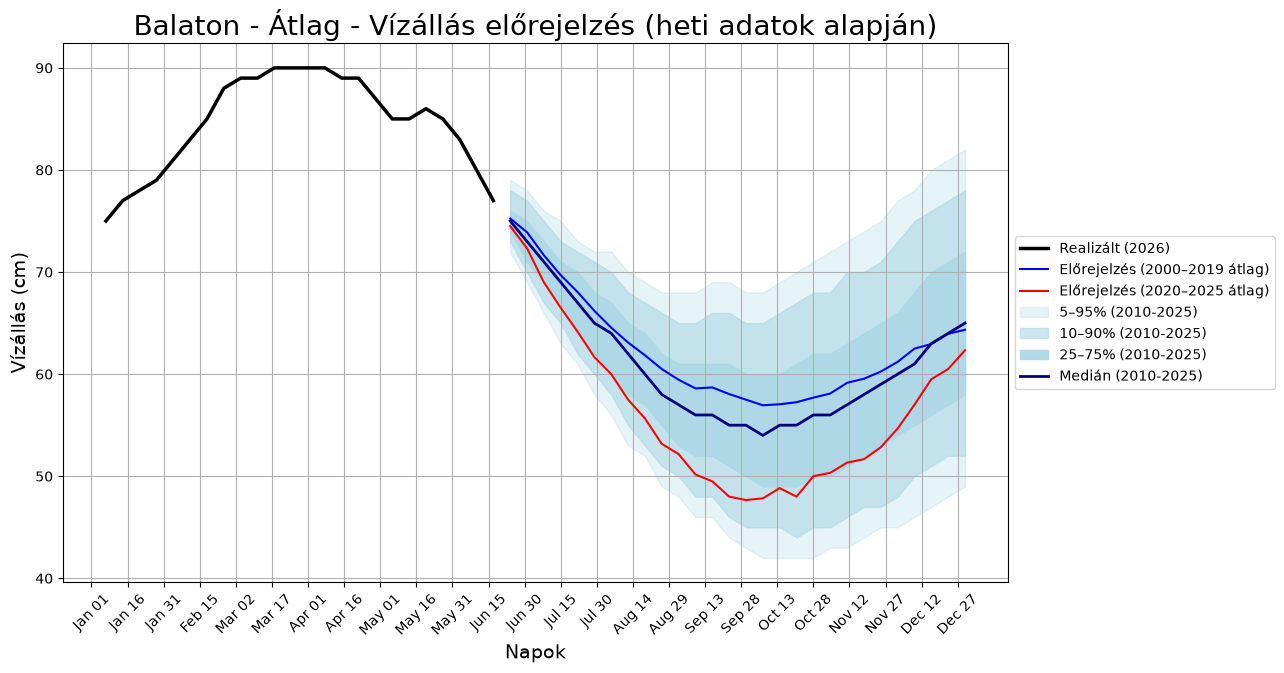

In [43]:
plt.figure(figsize=(14, 7))

# --- Realized history (actual measured weekly data) ---
plt.plot(
    realized["dayofyear"],
    realized["water_level"],
    color="black",
    linewidth=2.5,
    label=f"Realizált ({current_year})",
)

# --- Forecast lines ---
plt.plot(forecast_2000_2019, label="Előrejelzés (2000–2019 átlag)", color="blue")
plt.plot(forecast_2020_2025, label="Előrejelzés (2020–2025 átlag)", color="red")

# --- Fan chart shading ---
plt.fill_between(
    grid_days, p05, p95, color="lightblue", alpha=0.30, label="5–95% (2010-2025)"
)
plt.fill_between(
    grid_days, p10, p90, color="lightblue", alpha=0.60, label="10–90% (2010-2025)"
)
plt.fill_between(
    grid_days,
    result["p25"],
    result["p75"],
    color="lightblue",
    alpha=0.95,
    label="25–75% (2010-2025)",
)

# --- Fan chart median ---
plt.plot(grid_days, p50, color="navy", linewidth=2, label="Medián (2010-2025)")

# --- Titles, labels ---
plt.title(
    f"{TOWN} - Vízállás előrejelzés (heti adatok alapján)",
    fontsize=20,
)
plt.xlabel("Napok", fontsize=14)
plt.ylabel("Vízállás (cm)", fontsize=14)
plt.grid(True)

# --- Legend right side ---
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.8)

# --- X-axis date labels ---
plt.xticks(
    ticks=range(1, 366, 15),
    labels=date_labels[::15],
    rotation=45,
)
plt.savefig(
    ROOT / "exploration" / f"forecast_{TOWN_NICKNAME}.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [44]:
daily_last_7day.tail(1)

,timestamp,water_level,date,diff,year,month,day,dayofyear_raw,dayofyear
16970,2026-06-17 07:00:00,77,2026-06-17,-3.0,2026,6,17,168,168
